In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ---------------------------------------------------
# Load Data
# ---------------------------------------------------

investor = pd.read_csv(
    "C:\\Users\\tekam\\Downloads\\Data Science\\Data_Analyst_Portfolio_Project\\data\\processed\\investor_transactions_clean.csv"
)

fund = pd.read_csv(
    "C:\\Users\\tekam\\Downloads\\Data Science\\Data_Analyst_Portfolio_Project\\data\\raw\\01_fund_master.csv"
)

# ---------------------------------------------------
# Date Conversion
# ---------------------------------------------------

investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"]
)

# ---------------------------------------------------
# Merge Scheme Name
# ---------------------------------------------------

investor = investor.merge(

    fund[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

print("="*60)
print("Investor Data Loaded")
print("="*60)

print("Records :",len(investor))
print("Investors :",investor["investor_id"].nunique())

display(investor.head())

Investor Data Loaded
Records : 13048
Investors : 4392


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,scheme_name
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,Axis Bluechip Fund - Regular - Growth
1,INV004770,2024-01-01,102886,Lumpsum,92031,Gujarat,Surat,T30,18-25,Female,5.2,Mandate,Verified,UTI Mid Cap Fund - Regular - Growth
2,INV004648,2024-01-01,118634,SIP,17860,Maharashtra,Pune,T30,36-45,Male,54.3,Mandate,Pending,Nippon India Small Cap Fund - Regular - Growth
3,INV002432,2024-01-01,101208,SIP,3513,Haryana,Gurugram,T30,46-55,Female,48.1,Net Banking,Verified,ABSL Liquid Fund - Regular - Growth
4,INV002338,2024-01-01,120844,Lumpsum,292991,Delhi,New Delhi,T30,26-35,Male,23.6,UPI,Verified,Kotak Liquid Fund - Regular - Growth


In [2]:
# ---------------------------------------------------
# First Transaction Year
# ---------------------------------------------------

first_txn = (

    investor

    .groupby("investor_id")["transaction_date"]

    .min()

    .reset_index()

)

first_txn["Cohort Year"] = (

    first_txn["transaction_date"]

    .dt.year

)

first_txn = first_txn.rename(

    columns={

        "transaction_date":"First Transaction"

    }

)

display(first_txn.head())

,investor_id,First Transaction,Cohort Year
0,INV000001,2024-04-11,2024
1,INV000002,2024-03-10,2024
2,INV000003,2025-11-03,2025
3,INV000004,2024-01-05,2024
4,INV000005,2024-02-10,2024


In [3]:
# ---------------------------------------------------
# Merge Cohort
# ---------------------------------------------------

investor = investor.merge(

    first_txn[
        ["investor_id","Cohort Year"]
    ],

    on="investor_id",

    how="left"

)

display(investor.head())

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,scheme_name,Cohort Year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,Axis Bluechip Fund - Regular - Growth,2024
1,INV004770,2024-01-01,102886,Lumpsum,92031,Gujarat,Surat,T30,18-25,Female,5.2,Mandate,Verified,UTI Mid Cap Fund - Regular - Growth,2024
2,INV004648,2024-01-01,118634,SIP,17860,Maharashtra,Pune,T30,36-45,Male,54.3,Mandate,Pending,Nippon India Small Cap Fund - Regular - Growth,2024
3,INV002432,2024-01-01,101208,SIP,3513,Haryana,Gurugram,T30,46-55,Female,48.1,Net Banking,Verified,ABSL Liquid Fund - Regular - Growth,2024
4,INV002338,2024-01-01,120844,Lumpsum,292991,Delhi,New Delhi,T30,26-35,Male,23.6,UPI,Verified,Kotak Liquid Fund - Regular - Growth,2024


In [4]:
# ---------------------------------------------------
# Cohort Summary
# ---------------------------------------------------

cohort_summary = (

    investor

    .groupby("Cohort Year")

    .agg(

        Avg_SIP=("amount_inr","mean"),

        Total_Investment=("amount_inr","sum"),

        Investors=("investor_id","nunique")

    )

    .reset_index()

)

display(cohort_summary)

,Cohort Year,Avg_SIP,Total_Investment,Investors
0,2024,107823.151958,1348867631,3976
1,2025,97670.184015,52546559,416


In [5]:
# ---------------------------------------------------
# Top Fund Preference
# ---------------------------------------------------

fund_pref = (

    investor

    .groupby(

        ["Cohort Year","scheme_name"]

    )

    .size()

    .reset_index(name="Count")

)

top_pref = (

    fund_pref

    .sort_values(

        ["Cohort Year","Count"],

        ascending=[True,False]

    )

    .groupby("Cohort Year")

    .head(1)

)

display(top_pref)

,Cohort Year,scheme_name,Count
35,2024,SBI Small Cap Fund - Direct Plan - Growth,358
47,2025,DSP Midcap Fund - Regular - Growth,24


In [6]:
# ---------------------------------------------------
# Final Cohort Table
# ---------------------------------------------------

final = cohort_summary.merge(

    top_pref[

        [

            "Cohort Year",

            "scheme_name"

        ]

    ],

    on="Cohort Year",

    how="left"

)

final = final.rename(

    columns={

        "scheme_name":"Top Fund Preference"

    }

)

display(final)

,Cohort Year,Avg_SIP,Total_Investment,Investors,Top Fund Preference
0,2024,107823.151958,1348867631,3976,SBI Small Cap Fund - Direct Plan - Growth
1,2025,97670.184015,52546559,416,DSP Midcap Fund - Regular - Growth


In [7]:
# ---------------------------------------------------
# Save CSV
# ---------------------------------------------------

os.makedirs(

    "data/processed",

    exist_ok=True

)

final.to_csv(

    "C:\\Users\\tekam\\Downloads\\Data Science\\Data_Analyst_Portfolio_Project\\data\\processed\\investor_cohort_analysis.csv",

    index=False

)

print("Saved Successfully")

Saved Successfully


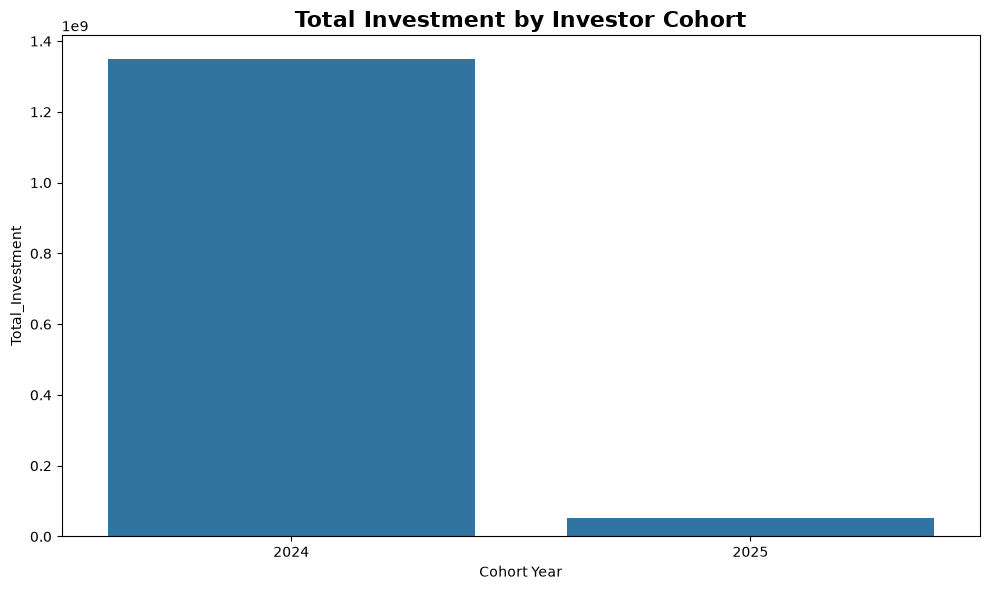

In [8]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=final,

    x="Cohort Year",

    y="Total_Investment"

)

plt.title(

    "Total Investment by Investor Cohort",

    fontsize=16,

    weight="bold"

)

plt.tight_layout()

plt.savefig(

    "dashboard/investor_cohort_total_investment.png",

    dpi=300

)

plt.show()

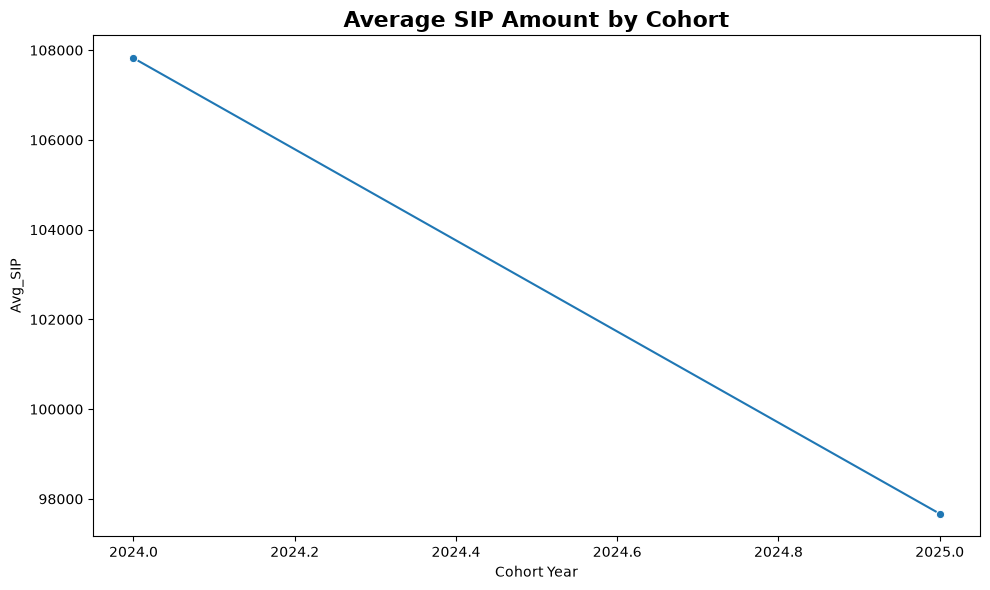

In [9]:
plt.figure(figsize=(10,6))

sns.lineplot(

    data=final,

    x="Cohort Year",

    y="Avg_SIP",

    marker="o"

)

plt.title(

    "Average SIP Amount by Cohort",

    fontsize=16,

    weight="bold"

)

plt.tight_layout()

plt.savefig(

    "dashboard/cohort_avg_sip.png",

    dpi=300

)

plt.show()

## Investor Cohort Analysis

Investors were grouped according to the year of their first transaction.

For each cohort the following metrics were calculated:

- Average SIP Amount
- Total Investment
- Number of Investors
- Top Fund Preference

Charts:
- Investor Cohort Total Investment
- Average SIP by Cohort